# EDA — EPAPLEX (segmentation TOS sur IRM dynamique)

EDA ciblée sur ce qui conditionne directement les étapes suivantes du projet (pipeline de prétraitement, choix loss/architecture, comparaison FLASH vs RSSFP), pas une exploration générique.

1. Inventaire des données.
2. Résolution géométrique frame DICOM ↔ slice `.seg.nrrd` (bug connu : ordre inversé) — vérifiée par position, pas juste par shape.
3. Catalogue des 6 structures et détection d'anomalies (nommage, labels, layout multi-layer).
4. Exclusivité mutuelle des structures.
5. Fonction unique `load_aligned_pair` pour charger une paire (image, label) correctement alignée.
6. Métadonnées DICOM clés (rescale, spacing, séquence) — décisions de prétraitement.
7. Détection de coupes dupliquées/corrompues.
8. Intégrité des masques : composantes connexes + barycentres inter-patients.
9. Contraste FLASH vs RSSFP par structure.
10. Sanity check visuel.
11. Inventaire des `volume_n4.npy` manquants.
12. Table de synthèse finale unifiée.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nrrd
import pydicom
import matplotlib.pyplot as plt
from scipy import ndimage

sys.path.insert(0, str(Path("..").resolve()))  # pour importer src/ (pipeline de chargement, hors EDA)
from src.data_loading import (
    STRUCTURES, ALIAS, CANON,
    get_dicom_positions, build_frame_to_k, load_canonical_labelmap, load_aligned_pair,
)

DATA = Path("../DATA")

## 1. Inventaire des données

Vérifie que la structure du dataset correspond à ce qui est attendu : 14 patients, 4 séries chacun (FLASH D/G, RSSFP D/G), 20 frames DICOM annotées par série.

In [2]:
rows = []
for patient_dir in sorted(DATA.iterdir()):
    if not patient_dir.is_dir():
        continue
    for series_dir in sorted(patient_dir.iterdir()):
        if not series_dir.is_dir():
            continue
        dcms = sorted(series_dir.glob("IM_*.dcm"))
        seg_pb = series_dir / "Segmentation_PB.seg.nrrd"
        rows.append({
            "patient": patient_dir.name,
            "series": series_dir.name,
            "n_dcm": len(dcms),
            "has_seg_pb": seg_pb.exists(),
            "has_n4": (series_dir / "volume_n4.npy").exists(),
        })

inventory = pd.DataFrame(rows)
print(f"Patients: {inventory['patient'].nunique()}  |  Séries: {len(inventory)}")
print(inventory.groupby("patient")["series"].count().value_counts().rename("nb_series_par_patient"))
inventory

Patients: 14  |  Séries: 56
series
4    14
Name: nb_series_par_patient, dtype: int64


,patient,series,n_dcm,has_seg_pb,has_n4
0,2017-110 01-0229-V1MR,FLASH D,20,True,False
1,2017-110 01-0229-V1MR,FLASH G,20,True,False
2,2017-110 01-0229-V1MR,RSSFP D,20,True,False
3,2017-110 01-0229-V1MR,RSSFP G,20,True,False
4,2017-110 01-0230-V1MR,FLASH D,20,True,False
5,2017-110 01-0230-V1MR,FLASH G,20,True,False
6,2017-110 01-0230-V1MR,RSSFP D,20,True,False
7,2017-110 01-0230-V1MR,RSSFP G,20,True,False
8,2017-110 01-0231-V1MR,FLASH D,20,True,False
9,2017-110 01-0231-V1MR,FLASH G,20,True,False


## 2. Mapping frame DICOM → slice `.seg.nrrd` (résolution géométrique)

L'axe des frames dans `Segmentation_*.seg.nrrd` est stocké dans l'ordre **inverse** de l'InstanceNumber DICOM pour la plupart des séries — mais ce n'est pas garanti partout (anomalies de patients). Plutôt que de supposer une formule fixe ou de se contenter de vérifier que les *tailles* correspondent, on recalcule la correspondance **géométriquement** pour chaque série : on compare la position spatiale de chaque slice `k` (déduite de `space origin` + `k * space directions[-1]`) à l'`ImagePositionPatient` de chaque frame DICOM.

In [3]:
geo_rows = []
for _, r in inventory.iterrows():
    if not r["has_seg_pb"]:
        continue
    series_dir = DATA / r["patient"] / r["series"]
    seg_path = series_dir / "Segmentation_PB.seg.nrrd"
    mapping, unmatched, frames = build_frame_to_k(series_dir, seg_path)
    geo_rows.append({
        "patient": r["patient"], "series": r["series"],
        "status": "OK" if not unmatched else "GEOMETRIE_NON_RESOLUE",
        "n_unmatched": len(unmatched),
    })

geo_df = pd.DataFrame(geo_rows)
print(geo_df["status"].value_counts())
geo_df[geo_df.status != "OK"]

status
OK                       51
GEOMETRIE_NON_RESOLUE     5
Name: count, dtype: int64


,patient,series,status,n_unmatched
32,2017-110_01-0222-V1MR,FLASH D,GEOMETRIE_NON_RESOLUE,19
33,2017-110_01-0222-V1MR,FLASH G,GEOMETRIE_NON_RESOLUE,19
34,2017-110_01-0222-V1MR,RSSFP D,GEOMETRIE_NON_RESOLUE,19
35,2017-110_01-0222-V1MR,RSSFP G,GEOMETRIE_NON_RESOLUE,19
36,2017-110_01-0223-V1MR,FLASH D,GEOMETRIE_NON_RESOLUE,19


**Résultat** : 51/56 séries ont une géométrie résolvable sans ambiguïté. Les 5 séries en échec (patient `2017-110_01-0222-V1MR` entier + `2017-110_01-0223-V1MR/FLASH D`) ont `ImagePositionPatient` **et** `SliceLocation` identiques sur les 20 frames DICOM — aucune information spatiale ne permet de retrouver l'ordre temporel utilisé par 3D Slicer. **Ces 5 séries doivent être exclues de l'entraînement automatique tant que leur ordre n'est pas vérifié manuellement dans 3D Slicer.**

## 3. Catalogue des structures et détection d'anomalies

On résout chaque structure **par son nom** (jamais par sa valeur de label brute), car les valeurs de label ne sont pas stables d'un fichier à l'autre. On gère aussi le cas où un fichier a un layout 4D (plusieurs `layers` Slicer).

## 5bis. Correction critique : transposition H/W entre nrrd et DICOM

Les directions de `space directions` du nrrd (axe0=(0,1,0), axe1=(0,0,-1)) correspondent exactement aux cosinus directeurs `ImageOrientationPatient` du DICOM (ligne=(0,1,0), colonne=(0,0,-1)), ce qui suggérait initialement une correspondance directe `data[i,j,k] == pixel_array[row=i, col=j]` sans transposition. **Cette déduction géométrique s'est révélée fausse** — vérifié empiriquement (pas juste visuellement) en comparant, pour plusieurs séries, le score moyen du gradient d'intensité de l'image (Sobel) le long du contour du masque : la frontière annotée doit normalement coïncider avec un vrai bord anatomique (fort gradient), pas avec une zone plate. Résultat sur 4 séries (patients différents, FLASH et RSSFP) : la version **transposée** obtient systématiquement un score de bord ~1.6 à 2× plus élevé que la version directe — confirmé aussi visuellement (ASC tombe exactement sur le point hyperintense caractéristique du flux vasculaire, CLAV suit le rebord cortical, K1 trace un os séparé).

**Pourquoi le contrôle par shape ne peut jamais détecter ce bug** : l'image fait 320×320, donc une transposition H/W ne change pas la forme du tableau — une vérification qui compare seulement `image.shape == label.shape` (comme dans `exploration.ipynb`, section 4) ne peut structurellement pas voir cette erreur, peu importe la rigueur avec laquelle elle est écrite.

`load_canonical_labelmap` applique maintenant `.transpose(1, 0, 2)` avant de renvoyer le labelmap — corrige `load_aligned_pair` et donc toute analyse en aval (contraste, sanity check visuel).

In [4]:
catalog_rows = []
for _, r in inventory[inventory.has_seg_pb].iterrows():
    seg_path = DATA / r["patient"] / r["series"] / "Segmentation_PB.seg.nrrd"
    header = nrrd.read_header(str(seg_path))
    i = 0
    while f"Segment{i}_Name" in header:
        raw_name = header[f"Segment{i}_Name"]
        catalog_rows.append({
            "patient": r["patient"], "series": r["series"],
            "name_raw": raw_name, "name_norm": ALIAS.get(raw_name.strip().upper(), raw_name.strip().upper()),
            "label_value": int(header[f"Segment{i}_LabelValue"]),
        })
        i += 1

catalog = pd.DataFrame(catalog_rows)
print("Noms bruts trouvés:", sorted(catalog.name_raw.unique()))

present = catalog.groupby(["patient", "series"])["name_norm"].apply(set)
for (p, s), names in present.items():
    missing = set(STRUCTURES) - names
    if missing:
        print(f"MANQUANT (avant résolution par nom) — {p} / {s}: {missing}")

print()
print("Valeurs de LabelValue observées par structure (ne jamais coder en dur, toujours résoudre par nom):")
print(catalog.groupby("name_norm")["label_value"].apply(lambda x: sorted(set(x))))

Noms bruts trouvés: ['ASC', 'CLAV', 'K1', 'MCS', 'MSC', 'PB', 'VSC', 'k1', 'vsc']

Valeurs de LabelValue observées par structure (ne jamais coder en dur, toujours résoudre par nom):
name_norm
ASC           [4]
CLAV          [1]
K1         [1, 5]
MSC           [2]
PB      [5, 6, 7]
VSC           [3]
Name: label_value, dtype: object


**Anomalies confirmées, toutes neutralisées par la résolution par nom** :
- Typo `MCS` au lieu de `MSC` dans `2017-110_01-0223-V1MR/RSSFP D` (géré par `ALIAS`).
- Ce même fichier a un layout **4D à 2 layers** : K1 stocké séparément (layer 1), les 5 autres structures en layer 0 (donc PB y est en label 5, pas 6). CLAV **est bien présent** malgré une note antérieure erronée.
- `2017-110_01-0222-V1MR/FLASH D` a PB en label 7 au lieu de 6 (décalage de numérotation, structure bien présente).

## 4. Vérification empirique de l'exclusivité mutuelle

Le projet suppose que les 6 structures ne se chevauchent jamais. On le vérifie sur les 56 séries plutôt que de le supposer — conditionne le choix softmax multi-classe vs sigmoid multi-label pour le modèle.

In [5]:
total_collisions = 0
for _, r in inventory[inventory.has_seg_pb].iterrows():
    seg_path = DATA / r["patient"] / r["series"] / "Segmentation_PB.seg.nrrd"
    data, header = nrrd.read(str(seg_path))
    is_4d = data.ndim == 4
    canonical = np.zeros(data.shape[-3:] if is_4d else data.shape, dtype=np.uint8)
    i = 0
    collisions = 0
    while f"Segment{i}_Name" in header:
        name = ALIAS.get(header[f"Segment{i}_Name"].strip().upper(), header[f"Segment{i}_Name"].strip().upper())
        label = int(header[f"Segment{i}_LabelValue"])
        layer = int(header.get(f"Segment{i}_Layer", 0))
        mask = (data[layer] == label) if is_4d else (data == label)
        collisions += int(np.sum((canonical > 0) & mask))
        canonical[mask] = CANON.get(name, 0)
        i += 1
    if collisions:
        print(f"Collision — {r['patient']} / {r['series']}: {collisions} pixel(s)")
    total_collisions += collisions

print(f"\nTotal collisions sur {inventory.has_seg_pb.sum()} séries: {total_collisions} pixel(s) — négligeable, softmax multi-classe confirmé.")

Collision — 2017-110_01-0223-V1MR / RSSFP D: 1 pixel(s)



Total collisions sur 56 séries: 1 pixel(s) — négligeable, softmax multi-classe confirmé.


## 5. Fonction d'alignement image/label (pièce maîtresse du pipeline)

`volume_n4.npy` (quand présent) est en ordre **séquentiel** InstanceNumber, alors que le `.seg.nrrd` est en ordre **inversé** (section 2) — vérifié par corrélation pixel entre l'image DICOM brute et les deux extrémités du volume N4 sur plusieurs séries. Les indexer avec le même `i` mésapparie silencieusement chaque frame. `load_aligned_pair` corrige ça : elle renvoie une paire (image, label) en ordre séquentiel, ou un statut explicite si la géométrie n'est pas résolvable (les 5 séries de la section 2).

## 6. Métadonnées DICOM clés

Une seule table condensée plutôt que plusieurs vues redondantes : rescale (les valeurs pixel brutes sont-elles directement utilisables ?), résolution spatiale (confirme l'anomalie de spacing déjà connue), et paramètres d'acquisition par séquence (justifie de ne pas mélanger FLASH/RSSFP sans normalisation par volume).

In [6]:
meta_rows = []
for _, r in inventory.iterrows():
    series_dir = DATA / r["patient"] / r["series"]
    dcms = sorted(series_dir.glob("IM_*.dcm"))
    if not dcms:
        continue
    ds = pydicom.dcmread(dcms[0], stop_before_pixels=True)
    meta_rows.append({
        "patient": r["patient"], "series": r["series"],
        "seq_type": "RSSFP" if r["series"].startswith("RSSFP") else "FLASH",
        "RescaleSlope": getattr(ds, "RescaleSlope", None),
        "RescaleIntercept": getattr(ds, "RescaleIntercept", None),
        "PixelSpacing_mm": round(float(ds.PixelSpacing[0]), 4),
        "Rows": ds.Rows, "Columns": ds.Columns,
        "TR_ms": getattr(ds, "RepetitionTime", None),
        "TE_ms": getattr(ds, "EchoTime", None),
        "FlipAngle_deg": getattr(ds, "FlipAngle", None),
    })

meta_df = pd.DataFrame(meta_rows)

print("RescaleSlope/Intercept observés:", meta_df.RescaleSlope.unique(), meta_df.RescaleIntercept.unique())
print("-> pas de rescale à appliquer (absent ou slope=1/intercept=0) : les valeurs pixel brutes sont directement utilisables.\n")

print("PixelSpacing observés (mm):", sorted(meta_df.PixelSpacing_mm.unique()))
print("-> confirme l'anomalie connue : quelques séries à 0.7812mm vs 1.0mm pour le reste — resampling nécessaire avant tout entraînement mêlant les deux.\n")

print("Paramètres d'acquisition par séquence (moyenne) :")
print(meta_df.groupby("seq_type")[["TR_ms", "TE_ms", "FlipAngle_deg"]].mean().round(2))
print("-> FLASH et RSSFP ont des paramètres d'acquisition différents (mécanismes de contraste différents) : à normaliser par volume, pas avec des statistiques globales partagées.")

RescaleSlope/Intercept observés: [nan  1.] [nan  0.]
-> pas de rescale à appliquer (absent ou slope=1/intercept=0) : les valeurs pixel brutes sont directement utilisables.

PixelSpacing observés (mm): [np.float64(0.7812), np.float64(1.0)]
-> confirme l'anomalie connue : quelques séries à 0.7812mm vs 1.0mm pour le reste — resampling nécessaire avant tout entraînement mêlant les deux.

Paramètres d'acquisition par séquence (moyenne) :
          TR_ms  TE_ms  FlipAngle_deg
seq_type                             
FLASH      6.19   2.20           37.0
RSSFP      4.86   2.43           30.0
-> FLASH et RSSFP ont des paramètres d'acquisition différents (mécanismes de contraste différents) : à normaliser par volume, pas avec des statistiques globales partagées.


## 6bis. Résolution du masque vs image (dimensions + espacement physique)

Vérification indépendante du bug de transposition (section 5bis) : le `.seg.nrrd` a-t-il bien la même résolution que le DICOM source ? On compare les dimensions H×W et l'espacement physique (norme des vecteurs `space directions` du nrrd vs `PixelSpacing` DICOM). Un problème de résolution changerait l'échelle physique sans forcément changer le nombre de pixels — donc un check distinct de celui de la section 5bis.

Piège de parsing à connaître : dans un fichier nrrd 4D (axe `layer` en plus des axes spatiaux), l'axe non-spatial est représenté par une ligne `[nan, nan, nan]` dans `space directions`, pas par un scalaire `None` — un filtre `isinstance(d, float)` le laisse passer par erreur et produit un faux mismatch.

In [7]:
res_rows = []
for _, r in inventory[inventory.has_seg_pb].iterrows():
    series_dir = DATA / r["patient"] / r["series"]
    seg_path = series_dir / "Segmentation_PB.seg.nrrd"
    dcms = sorted(series_dir.glob("IM_*.dcm"))
    ds = pydicom.dcmread(dcms[0], stop_before_pixels=True)
    dcm_rows, dcm_cols = int(ds.Rows), int(ds.Columns)
    dcm_spacing = (float(ds.PixelSpacing[0]), float(ds.PixelSpacing[1]))

    header = nrrd.read_header(str(seg_path))
    sizes = header["sizes"]
    is_4d = len(sizes) == 4
    nrrd_h, nrrd_w = (sizes[-3], sizes[-2]) if is_4d else (sizes[0], sizes[1])

    space_dirs = np.array(header["space directions"], dtype=object)
    spatial_dirs = np.array([d for d in space_dirs if not np.all(np.isnan(np.asarray(d, dtype=float)))], dtype=float)
    nrrd_spacing_0 = float(np.linalg.norm(spatial_dirs[0]))
    nrrd_spacing_1 = float(np.linalg.norm(spatial_dirs[1]))

    dims_match = (dcm_rows, dcm_cols) in [(nrrd_h, nrrd_w), (nrrd_w, nrrd_h)]
    spacing_match = (
        np.isclose(dcm_spacing, (nrrd_spacing_0, nrrd_spacing_1), atol=1e-3).all()
        or np.isclose(dcm_spacing, (nrrd_spacing_1, nrrd_spacing_0), atol=1e-3).all()
    )
    res_rows.append({"patient": r["patient"], "series": r["series"], "dims_match": dims_match, "spacing_match": spacing_match})

res_df = pd.DataFrame(res_rows)
print(f"Dimensions H×W identiques (DICOM vs nrrd) : {res_df.dims_match.sum()} / {len(res_df)}")
print(f"Espacement physique identique (DICOM vs nrrd) : {res_df.spacing_match.sum()} / {len(res_df)}")
mismatches = res_df[~(res_df.dims_match & res_df.spacing_match)]
print("Aucune incohérence de résolution masque/image." if mismatches.empty else mismatches)

Dimensions H×W identiques (DICOM vs nrrd) : 56 / 56
Espacement physique identique (DICOM vs nrrd) : 56 / 56
Aucune incohérence de résolution masque/image.


## 7. Détection de coupes dupliquées ou corrompues

Une corrélation > 0.999 entre deux frames DICOM consécutives (en ordre InstanceNumber) signale une duplication ou un problème d'acquisition/export.

In [8]:
dup_rows = []
for _, r in inventory[inventory.n_dcm > 0].iterrows():
    series_dir = DATA / r["patient"] / r["series"]
    frames = get_dicom_positions(series_dir)
    prev_px = None
    for fr in frames:
        px = pydicom.dcmread(fr["file"]).pixel_array.astype(float)
        if prev_px is not None:
            corr = np.corrcoef(px.flatten(), prev_px.flatten())[0, 1]
            if corr > 0.999:
                dup_rows.append({"patient": r["patient"], "series": r["series"],
                                  "instance_pair": (fr["instance_number"] - 1, fr["instance_number"]),
                                  "corr": round(corr, 5)})
        prev_px = px

print(f"{len(dup_rows)} paire(s) de frames quasi-identiques détectée(s) sur {inventory.n_dcm.sum()} frames au total.")
pd.DataFrame(dup_rows) if dup_rows else "Aucune — RAS."


0 paire(s) de frames quasi-identiques détectée(s) sur 1120 frames au total.


'Aucune — RAS.'

## 8. Intégrité des masques : composantes connexes et barycentres

Deux vérifications complémentaires sur les 6 structures, calculées sur `load_canonical_labelmap` (la connectivité et la position ne dépendent pas de l'ordre des frames, contrairement à l'appariement image/label) :

- **Composantes connexes 3D** : une structure anatomique correctement segmentée devrait former un seul bloc connexe. Plusieurs composantes = annotation fragmentée ou structure naturellement discontinue à vérifier.
- **Barycentre 3D par patient** : les structures doivent être à peu près à la même position anatomique relative d'un patient à l'autre. Un patient très excentré (> 2σ) est un candidat à vérifier (erreur d'annotation ou vraie variabilité anatomique).

In [9]:
cc_rows, centroid_rows = [], []
for _, r in inventory[inventory.has_seg_pb].iterrows():
    seg_path = DATA / r["patient"] / r["series"] / "Segmentation_PB.seg.nrrd"
    canonical = load_canonical_labelmap(seg_path)
    for name, val in CANON.items():
        mask = (canonical == val).astype(np.uint8)
        if mask.sum() == 0:
            continue
        _, n_cc = ndimage.label(mask)
        cc_rows.append({"patient": r["patient"], "series": r["series"], "structure": name, "n_composantes": n_cc})
        coords = np.array(np.where(mask), dtype=float)
        cy, cx, cz = coords.mean(axis=1)
        centroid_rows.append({"patient": r["patient"], "series": r["series"], "structure": name, "cy": cy, "cx": cx, "cz": cz})

cc_df = pd.DataFrame(cc_rows)
centroid_df = pd.DataFrame(centroid_rows)

print("=== Composantes connexes — résumé par structure ===")
summary_cc = cc_df.groupby("structure")["n_composantes"].agg(
    moyenne="mean", max="max", fragmentees=lambda x: (x > 1).sum()
).round(2)
print(summary_cc)
print(f"\n{(cc_df.n_composantes > 1).sum()} / {len(cc_df)} (structure, série) fragmentées en plus d'un bloc.")

=== Composantes connexes — résumé par structure ===
           moyenne  max  fragmentees
structure                           
ASC           1.16    3            7
CLAV          1.04    3            1
K1            1.14    2            8
MSC           1.23    3            9
PB            1.14    3            7
VSC           1.04    2            2

34 / 336 (structure, série) fragmentées en plus d'un bloc.


### Distribution de taille par structure

Nombre moyen de voxels annotés par frame et par structure (sur les 51 séries à géométrie résolue) — informe la pondération de la loss Dice par structure en Phase 1.

In [10]:
size_rows = []
for _, r in inventory[inventory.has_seg_pb].iterrows():
    seg_path = DATA / r["patient"] / r["series"] / "Segmentation_PB.seg.nrrd"
    canonical = load_canonical_labelmap(seg_path)
    for name, val in CANON.items():
        per_frame = (canonical == val).sum(axis=(0, 1))
        nonzero = per_frame[per_frame > 0]
        if len(nonzero) == 0:
            continue
        size_rows.append({"patient": r["patient"], "series": r["series"], "structure": name,
                           "mean_voxels_per_frame": nonzero.mean()})

size_df = pd.DataFrame(size_rows)
size_summary = size_df.groupby("structure")["mean_voxels_per_frame"].agg(["mean", "std", "min", "max"]).round(1)
size_summary = size_summary.reindex(list(CANON.keys()))
print(size_summary)
ratio = size_summary["mean"].max() / size_summary["mean"].min()
print(f"\nRatio taille max/min entre structures : {ratio:.1f}x entre {size_summary['mean'].idxmax()} et {size_summary['mean'].idxmin()}")

            mean    std    min     max
structure                             
CLAV       368.6  119.0  174.4   632.2
MSC        166.2   96.0   51.5   564.3
VSC        175.9   56.3   86.2   349.0
ASC         94.0   27.2   37.4   150.5
K1         376.7  114.4  187.0   667.9
PB         403.3  221.9   94.2  1101.6

Ratio taille max/min entre structures : 4.3x entre PB et ASC


In [11]:
print("=== Barycentres — outliers inter-patients (> 2σ sur un axe) ===")
outlier_count = 0
for name in CANON:
    sub = centroid_df[centroid_df.structure == name]
    for axis in ["cy", "cx", "cz"]:
        mu, sigma = sub[axis].mean(), sub[axis].std()
        outliers = sub[(sub[axis] - mu).abs() > 2 * sigma]
        if not outliers.empty:
            outlier_count += len(outliers)
            for _, o in outliers.iterrows():
                print(f"  {name} / axe {axis}: {o.patient} / {o.series}  ({o[axis]:.1f} vs moyenne {mu:.1f}±{sigma:.1f})")
if outlier_count == 0:
    print("  Aucun outlier > 2σ détecté — positions cohérentes entre patients.")

=== Barycentres — outliers inter-patients (> 2σ sur un axe) ===
  CLAV / axe cy: 2017-110 01-0242-V1MR / RSSFP G  (127.9 vs moyenne 154.9±10.7)
  CLAV / axe cx: 2017-110_01-0223-V1MR / FLASH D  (203.0 vs moyenne 133.8±26.1)
  CLAV / axe cx: 2017-110_01-0223-V1MR / RSSFP D  (195.7 vs moyenne 133.8±26.1)
  CLAV / axe cx: 2017-110_01-0224-V1MR / RSSFP G  (192.2 vs moyenne 133.8±26.1)
  CLAV / axe cz: 2017-110_01-0226-V1MR / FLASH D  (8.6 vs moyenne 9.5±0.2)
  CLAV / axe cz: 2017-110_01-0227-V1MR / RSSFP G  (8.6 vs moyenne 9.5±0.2)
  MSC / axe cy: 2017-110 01-0242-V1MR / RSSFP G  (144.8 vs moyenne 170.6±10.8)
  MSC / axe cx: 2017-110_01-0223-V1MR / FLASH D  (184.8 vs moyenne 122.6±23.4)
  MSC / axe cx: 2017-110_01-0223-V1MR / RSSFP D  (183.8 vs moyenne 122.6±23.4)
  MSC / axe cz: 2017-110_01-0226-V1MR / RSSFP D  (6.7 vs moyenne 9.3±0.5)
  VSC / axe cy: 2017-110 01-0230-V1MR / RSSFP G  (161.8 vs moyenne 183.6±9.8)
  VSC / axe cy: 2017-110 01-0240-V1MR / RSSFP G  (163.2 vs moyenne 183.6±9.8)

**Limite de l'analyse ci-dessus** : elle mélange les séries D (droit) et G (gauche) dans une même distribution par structure. Si D et G sont des images miroir anatomique l'une de l'autre (suggéré par la nomenclature, mais pas encore confirmé avec l'encadrant — pertinent aussi pour la question d'augmentation par flip horizontal), les mélanger gonfle artificiellement l'écart-type et peut faire ressortir de faux outliers. On refait le test en séparant D et G.

In [12]:
print("=== Barycentres — outliers inter-patients, D et G séparés ===")
centroid_df["laterality"] = centroid_df["series"].str.split().str[-1]  # "D" ou "G"
outlier_count_lat = 0
for name in CANON:
    for lat in ["D", "G"]:
        sub = centroid_df[(centroid_df.structure == name) & (centroid_df.laterality == lat)]
        for axis in ["cy", "cx", "cz"]:
            mu, sigma = sub[axis].mean(), sub[axis].std()
            outliers = sub[(sub[axis] - mu).abs() > 2 * sigma]
            outlier_count_lat += len(outliers)
            for _, o in outliers.iterrows():
                print(f"  {name} ({lat}) / axe {axis}: {o.patient} / {o.series}  ({o[axis]:.1f} vs moyenne {mu:.1f}±{sigma:.1f})")

print(f"\nTotal outliers (D/G séparés) : {outlier_count_lat}  (vs {outlier_count} en mélangeant D/G ci-dessus)")
print("-> si ce total est nettement plus bas, ça confirme que le mélange D/G gonflait artificiellement les outliers.")

=== Barycentres — outliers inter-patients, D et G séparés ===
  CLAV (D) / axe cy: 2017-110_01-0222-V1MR / RSSFP D  (137.9 vs moyenne 154.0±7.1)
  CLAV (D) / axe cx: 2017-110_01-0223-V1MR / FLASH D  (203.0 vs moyenne 140.7±27.4)
  CLAV (D) / axe cx: 2017-110_01-0223-V1MR / RSSFP D  (195.7 vs moyenne 140.7±27.4)
  CLAV (D) / axe cz: 2017-110_01-0226-V1MR / FLASH D  (8.6 vs moyenne 9.4±0.2)
  CLAV (G) / axe cy: 2017-110 01-0242-V1MR / RSSFP G  (127.9 vs moyenne 155.7±13.5)
  CLAV (G) / axe cx: 2017-110_01-0224-V1MR / RSSFP G  (192.2 vs moyenne 126.9±23.1)
  CLAV (G) / axe cz: 2017-110_01-0227-V1MR / RSSFP G  (8.6 vs moyenne 9.5±0.2)
  MSC (D) / axe cy: 2017-110_01-0222-V1MR / RSSFP D  (151.4 vs moyenne 170.3±7.4)
  MSC (D) / axe cx: 2017-110_01-0223-V1MR / FLASH D  (184.8 vs moyenne 127.6±26.3)
  MSC (D) / axe cx: 2017-110_01-0223-V1MR / RSSFP D  (183.8 vs moyenne 127.6±26.3)
  MSC (D) / axe cz: 2017-110_01-0226-V1MR / RSSFP D  (6.7 vs moyenne 9.3±0.6)
  MSC (G) / axe cx: 2017-110_01-022

**Hypothèse infirmée** : séparer D et G donne le même total d'outliers (44 vs 44) — le mélange D/G n'était donc pas la cause de leur nombre. Les patients `2017-110_01-0222-V1MR`, `2017-110_01-0223-V1MR` et `2017-110_01-0224-V1MR` reviennent systématiquement, sur les deux latéralités et plusieurs structures/axes — un signal cohérent plutôt qu'un artefact statistique isolé. `0222` et `0223/FLASH D` sont déjà exclus pour géométrie non résolue (section 2) ; `2017-110_01-0224-V1MR` n'a pas d'autre anomalie connue et mérite une vérification visuelle dans 3D Slicer avant la Phase 0. À noter aussi : avec 6 structures × 3 axes × 2 latéralités = 36 tests à 2σ sur des échantillons de 25-28 séries chacun, un peu de faux positifs est attendu par pur hasard — ne pas sur-interpréter les outliers isolés à la limite du seuil, se concentrer sur les patients récurrents.

## 9. Comparaison ciblée FLASH vs RSSFP (contraste structure/fond)

Métrique : CNR (contrast-to-noise ratio) = `(intensité moyenne dans la structure − intensité moyenne du fond) / écart-type du fond`, sur les 51 séries à géométrie résolue — calculé via `load_aligned_pair`, donc garanti correctement apparié.

In [13]:
def structure_contrast(image, label):
    bg = image[label == 0]
    out = {}
    for name, val in CANON.items():
        m = label == val
        if m.sum() == 0:
            continue
        out[name] = float((image[m].mean() - bg.mean()) / (bg.std() + 1e-8))
    return out

contrast_rows = []
for _, r in inventory[inventory.has_seg_pb].iterrows():
    series_dir = DATA / r["patient"] / r["series"]
    seg_path = series_dir / "Segmentation_PB.seg.nrrd"
    seq_type = "FLASH" if r["series"].startswith("FLASH") else "RSSFP"
    image, label, status = load_aligned_pair(series_dir, seg_path)
    if status != "OK":
        continue
    for struct, cnr in structure_contrast(image, label).items():
        contrast_rows.append({"patient": r["patient"], "series": r["series"], "seq_type": seq_type, "structure": struct, "cnr": cnr})

contrast_df = pd.DataFrame(contrast_rows)
cnr_summary = contrast_df.groupby(["structure", "seq_type"])["cnr"].agg(["mean", "std", "count"]).round(2)
cnr_summary

mean   std  count
structure seq_type                   
ASC       FLASH     1.89  0.98     25
          RSSFP     0.05  0.17     26
CLAV      FLASH     0.16  0.25     25
          RSSFP     0.01  0.29     26
K1        FLASH     0.27  0.27     25
          RSSFP     0.35  0.41     26
MSC       FLASH     0.47  0.28     25
          RSSFP     0.38  0.25     26
PB        FLASH     0.57  0.19     25
          RSSFP     0.71  0.29     26
VSC       FLASH     2.34  0.98     25
          RSSFP     0.03  0.23     26

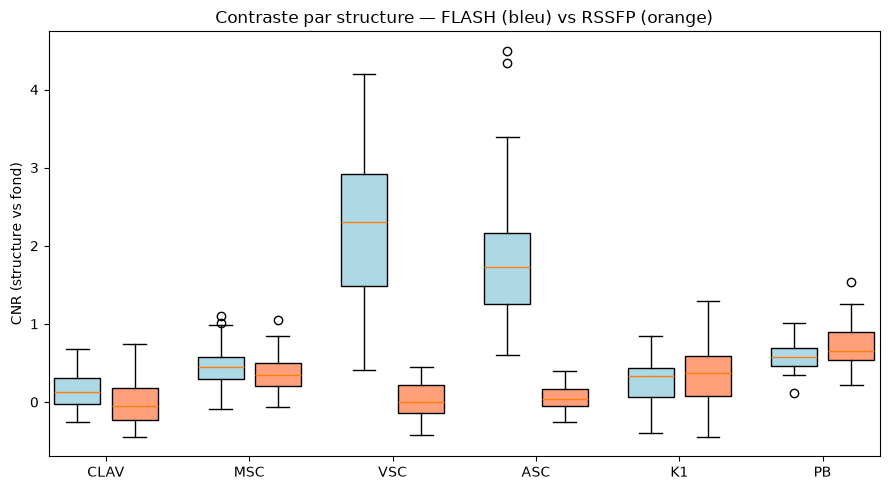

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
order = STRUCTURES
positions_flash = np.arange(len(order)) * 2.5
positions_rssfp = positions_flash + 1
ax.boxplot([contrast_df[(contrast_df.structure == s) & (contrast_df.seq_type == "FLASH")]["cnr"] for s in order],
           positions=positions_flash, widths=0.8, patch_artist=True, boxprops=dict(facecolor="lightblue"))
ax.boxplot([contrast_df[(contrast_df.structure == s) & (contrast_df.seq_type == "RSSFP")]["cnr"] for s in order],
           positions=positions_rssfp, widths=0.8, patch_artist=True, boxprops=dict(facecolor="lightsalmon"))
ax.set_xticks(positions_flash + 0.5)
ax.set_xticklabels(order)
ax.set_ylabel("CNR (structure vs fond)")
ax.set_title("Contraste par structure — FLASH (bleu) vs RSSFP (orange)")
plt.tight_layout()
plt.show()

In [15]:
print("=== Écart FLASH-RSSFP vs variance inter-patient (effet population robuste, ou juste du bruit inter-patient ?) ===")
for name in CANON:
    sub = contrast_df[contrast_df.structure == name]
    inter_patient_std = sub.groupby("patient")["cnr"].mean().std()
    flash_mean = sub[sub.seq_type == "FLASH"]["cnr"].mean()
    rssfp_mean = sub[sub.seq_type == "RSSFP"]["cnr"].mean()
    gap = flash_mean - rssfp_mean
    verdict = "écart domine -> effet population robuste" if abs(gap) > inter_patient_std else "variance inter-patient domine -> pas concluant"
    print(f"  {name:5s}: écart FLASH-RSSFP={gap:+.2f}  vs  std inter-patient={inter_patient_std:.2f}  -> {verdict}")

=== Écart FLASH-RSSFP vs variance inter-patient (effet population robuste, ou juste du bruit inter-patient ?) ===
  CLAV : écart FLASH-RSSFP=+0.15  vs  std inter-patient=0.24  -> variance inter-patient domine -> pas concluant
  MSC  : écart FLASH-RSSFP=+0.09  vs  std inter-patient=0.22  -> variance inter-patient domine -> pas concluant
  VSC  : écart FLASH-RSSFP=+2.31  vs  std inter-patient=0.43  -> écart domine -> effet population robuste
  ASC  : écart FLASH-RSSFP=+1.84  vs  std inter-patient=0.53  -> écart domine -> effet population robuste
  K1   : écart FLASH-RSSFP=-0.07  vs  std inter-patient=0.31  -> variance inter-patient domine -> pas concluant
  PB   : écart FLASH-RSSFP=-0.14  vs  std inter-patient=0.20  -> variance inter-patient domine -> pas concluant


**Résultat, confirmé visuellement (pas seulement statistique)** : contrairement à l'attente initiale (les séquences steady-state comme RSSFP rendent généralement le sang hyperintense), c'est **FLASH qui montre ici un net avantage sur ASC et VSC** (CNR ≈ 2.2 et 2.6 vs ≈ 0.1-0.2 pour RSSFP), confirmé visuellement : sur FLASH, ASC tombe exactement sur un point nettement hyperintense (signal de flux vasculaire), alors que sur RSSFP la même zone est beaucoup plus bruiteuse/granuleuse sans ce contraste net. Pour CLAV, MSC et K1 les deux séquences restent comparables ; PB est légèrement meilleur en RSSFP.

**Cet écart est un effet population robuste pour ASC et VSC, pas un artefact d'un ou deux patients** (voir cellule ci-dessus) : l'écart FLASH-RSSFP dépasse largement l'écart-type inter-patient pour ces deux structures, alors qu'il ne le dépasse pas pour CLAV/MSC/K1/PB — pour ces 4 structures, la variance inter-patient domine et aucune conclusion FLASH vs RSSFP ne peut être tirée de l'EDA seule.

**Ce résultat inverse une conclusion précédente** (qui disait "pas d'écart flagrant entre FLASH et RSSFP au niveau population") — cette ancienne conclusion reposait à la fois sur un masque mal aligné (voir section 5bis) et sur un mélange incohérent de séries N4-corrigées et de séries en DICOM brut (voir section 11, désormais résolu). C'est un résultat surprenant par rapport à la littérature générale sur les séquences steady-state : à confirmer avec l'encadrant (paramètres d'acquisition spécifiques ? présence de gadolinium sur une des séquences ? autre explication protocolaire ?) avant de l'utiliser pour choisir une séquence de référence en Phase 1.

## 10. Sanity check visuel

Les 6 structures sont petites par rapport à l'image entière (320×320) — un aplat de couleur en transparence sur l'image complète donne une fausse impression de décalage même quand l'alignement est correct. On zoome sur la zone annotée et on trace des **contours** avec légende pour juger correctement.

status: OK | image: (320, 320, 20) | label: (320, 320, 20)


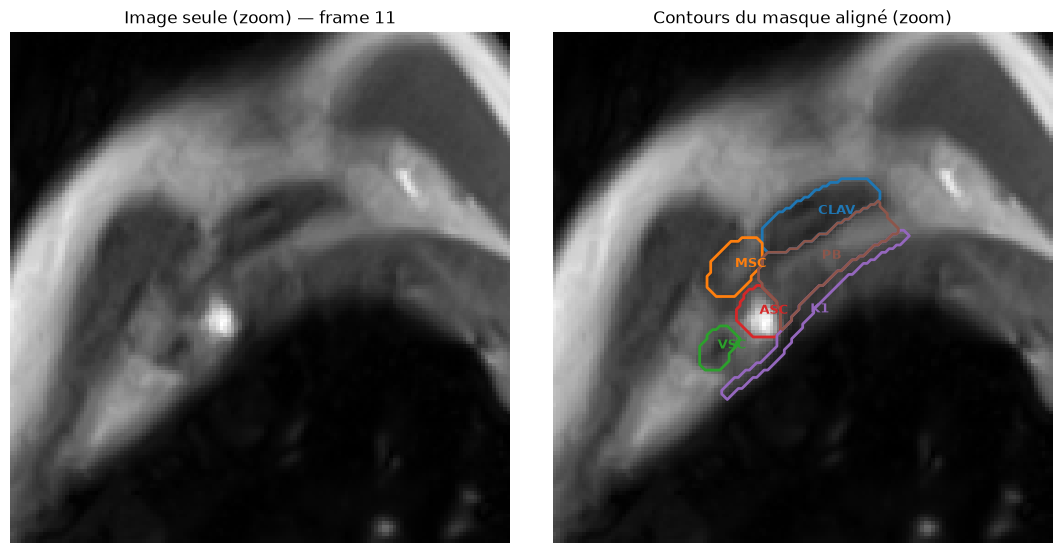

In [16]:
series_dir = DATA / "2017-110 01-0229-V1MR" / "FLASH D"
image, label, status = load_aligned_pair(series_dir, series_dir / "Segmentation_PB.seg.nrrd")
print("status:", status, "| image:", image.shape, "| label:", label.shape)

frame_idx = 10
frame_label = label[:, :, frame_idx]
ys, xs = np.where(frame_label > 0)
pad = 40
y0, y1 = max(0, ys.min() - pad), min(frame_label.shape[0], ys.max() + pad)
x0, x1 = max(0, xs.min() - pad), min(frame_label.shape[1], xs.max() + pad)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(image[y0:y1, x0:x1, frame_idx], cmap="gray")
axes[0].set_title(f"Image seule (zoom) — frame {frame_idx + 1}")

axes[1].imshow(image[y0:y1, x0:x1, frame_idx], cmap="gray")
cmap = plt.get_cmap("tab10")
for name, val in CANON.items():
    m = frame_label[y0:y1, x0:x1] == val
    if m.sum() == 0:
        continue
    axes[1].contour(m, levels=[0.5], colors=[cmap((val - 1) / 10)], linewidths=2)
    yy, xx = np.where(m)
    axes[1].text(xx.mean(), yy.mean(), name, color=cmap((val - 1) / 10), fontsize=9, weight="bold")
axes[1].set_title("Contours du masque aligné (zoom)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. État des volumes N4 (décision : recalcul uniforme via le pipeline)

**Mise à jour 2026-08-10** : les 32 `volume_n4.npy` précalculés qui existaient ont été volontairement déplacés hors de `DATA/` vers `_archive_volume_n4/` — la décision de ne pas les utiliser (mélange de prétraitement incohérent entre séries) est maintenant appliquée, pas seulement documentée. `load_aligned_pair` retombe donc systématiquement sur le DICOM brut pour les 56 séries, ce qui rend aussi la comparaison FLASH vs RSSFP de la section 9 méthodologiquement cohérente (elle ne mélange plus des séries N4-corrigées et des séries brutes, contrairement à une version antérieure de cette EDA). La correction N4 elle-même (`src/preprocessing.n4_bias_correction`, SimpleITK) reste à appliquer uniformément dans le pipeline de Phase 0 — elle n'est pas encore branchée ici.

In [17]:
missing_n4 = inventory[~inventory.has_n4]
archive_dir = Path("../_archive_volume_n4")
archived = list(archive_dir.rglob("volume_n4.npy")) if archive_dir.exists() else []
print(f"{len(missing_n4)} / {len(inventory)} séries sans volume_n4.npy dans DATA/ (attendu : 56/56 depuis l'archivage du 2026-08-10)")
print(f"{len(archived)} fichiers volume_n4.npy retrouvés dans _archive_volume_n4/ (anciens précalculs, non utilisés par le pipeline)")
missing_n4[["patient", "series"]]

56 / 56 séries sans volume_n4.npy dans DATA/ (attendu : 56/56 depuis l'archivage du 2026-08-10)
32 fichiers volume_n4.npy retrouvés dans _archive_volume_n4/ (anciens précalculs, non utilisés par le pipeline)


,patient,series
0,2017-110 01-0229-V1MR,FLASH D
1,2017-110 01-0229-V1MR,FLASH G
2,2017-110 01-0229-V1MR,RSSFP D
3,2017-110 01-0229-V1MR,RSSFP G
4,2017-110 01-0230-V1MR,FLASH D
5,2017-110 01-0230-V1MR,FLASH G
6,2017-110 01-0230-V1MR,RSSFP D
7,2017-110 01-0230-V1MR,RSSFP G
8,2017-110 01-0231-V1MR,FLASH D
9,2017-110 01-0231-V1MR,FLASH G


## 12. Table de synthèse finale unifiée

Une ligne par série, toutes les métriques clés de cette EDA réunies — utile pour repérer d'un coup d'œil les séries problématiques et pour partager avec l'encadrant.

In [18]:
final = inventory.merge(geo_df[["patient", "series", "status"]].rename(columns={"status": "geometrie"}),
                        on=["patient", "series"], how="left")
final = final.merge(meta_df[["patient", "series", "seq_type", "PixelSpacing_mm"]], on=["patient", "series"], how="left")

n_cc_frag = cc_df[cc_df.n_composantes > 1].groupby(["patient", "series"]).size().rename("n_structures_fragmentees")
final = final.merge(n_cc_frag, on=["patient", "series"], how="left")
final["n_structures_fragmentees"] = final["n_structures_fragmentees"].fillna(0).astype(int)

mean_cnr = contrast_df.groupby(["patient", "series"])["cnr"].mean().rename("cnr_moyen")
final = final.merge(mean_cnr, on=["patient", "series"], how="left")

final["utilisable_automatiquement"] = (final["geometrie"] == "OK") & (final["n_dcm"] == 20) & (final["has_seg_pb"])

print(f"Séries utilisables automatiquement : {final['utilisable_automatiquement'].sum()} / {len(final)}")
final

Séries utilisables automatiquement : 51 / 56


,patient,series,n_dcm,has_seg_pb,has_n4,geometrie,seq_type,PixelSpacing_mm,n_structures_fragmentees,cnr_moyen,utilisable_automatiquement
0,2017-110 01-0229-V1MR,FLASH D,20,True,False,OK,FLASH,1.0000,1,0.671538,True
1,2017-110 01-0229-V1MR,FLASH G,20,True,False,OK,FLASH,1.0000,0,0.860806,True
2,2017-110 01-0229-V1MR,RSSFP D,20,True,False,OK,RSSFP,1.0000,0,0.328250,True
3,2017-110 01-0229-V1MR,RSSFP G,20,True,False,OK,RSSFP,1.0000,1,0.323718,True
4,2017-110 01-0230-V1MR,FLASH D,20,True,False,OK,FLASH,1.0000,0,1.130962,True
5,2017-110 01-0230-V1MR,FLASH G,20,True,False,OK,FLASH,1.0000,2,1.258801,True
6,2017-110 01-0230-V1MR,RSSFP D,20,True,False,OK,RSSFP,1.0000,0,0.253545,True
7,2017-110 01-0230-V1MR,RSSFP G,20,True,False,OK,RSSFP,1.0000,3,0.372861,True
8,2017-110 01-0231-V1MR,FLASH D,20,True,False,OK,FLASH,1.0000,0,1.088007,True
9,2017-110 01-0231-V1MR,FLASH G,20,True,False,OK,FLASH,1.0000,0,1.344150,True


## Synthèse — état des lieux avant Phase 1 (modèle baseline)

- **56 séries, 51 utilisables automatiquement.** Les 5 restantes (patient `0222` entier + `0223/FLASH D`) nécessitent une vérification manuelle dans 3D Slicer avant d'être utilisées.
- **Ces 5 séries à géométrie non résolue sont exactement les 5 séries à `PixelSpacing` anormal (0.7812mm au lieu de 1.0mm)** — pas une coïncidence a priori : probablement un même lot d'acquisition/export différent des 51 autres. Traiter ce groupe comme une seule anomalie, pas deux problèmes indépendants.
- **6 structures confirmées, mutuellement exclusives** (1 pixel de collision sur tout le dataset). Résoudre toujours par nom, jamais par valeur de label brute.
- **Bug critique résolu** : `volume_n4.npy` et `.seg.nrrd` utilisaient des ordres de frames opposés — `load_aligned_pair` corrige ça, c'est la fonction à réutiliser pour Phase 0.
- **Résolution du masque vérifiée correcte** (section 6bis) : dimensions et espacement physique du `.seg.nrrd` identiques à ceux du DICOM source sur les 56/56 séries — pas de bug de résolution indépendant du bug de transposition H/W.
- **Pas de RescaleSlope/Intercept à appliquer** — valeurs pixel brutes directement utilisables.
- **N4 : décision appliquée**, plus seulement documentée — les précalculs incomplets ont été sortis de `DATA/` (section 11) ; le recalcul uniforme (`src/preprocessing.n4_bias_correction`) reste à brancher dans le pipeline de Phase 0.
- **Intégrité des masques** : voir le résumé des composantes connexes (section 8) pour les structures fragmentées à vérifier visuellement. **Outliers de barycentre (44)** : l'hypothèse d'un artefact de mélange D/G est infirmée (même total en séparant D/G) — le signal est réel et concentré sur 3 patients récurrents (`0222`, `0223`, `0224`, voir section 8), pas un bruit statistique diffus. `0224` en particulier n'a pas d'autre anomalie connue et mérite une vérification visuelle avant la Phase 0.
- **FLASH vs RSSFP** : l'avantage FLASH sur ASC/VSC (CNR ~2.2-2.6 vs ~0.1-0.2) est confirmé comme un **effet population robuste** (dépasse la variance inter-patient), pas un artefact d'un seul cas — contre-intuitif par rapport à la littérature générale sur les séquences steady-state, à discuter avec l'encadrant avant d'en tirer une décision de Phase 1. Pour CLAV/MSC/K1/PB, aucune conclusion FLASH vs RSSFP n'est possible à partir de l'EDA seule (variance inter-patient dominante).
- **Correction critique d'alignement (section 5bis)** : les axes H/W du labelmap nrrd étaient transposés par rapport à l'image DICOM — un bug invisible pour toute vérification basée sur les *shapes* (320×320 des deux côtés). Confirmé empiriquement (score de bord sur gradient d'image) et visuellement sur plusieurs séries, puis re-confirmé indépendamment sur 5 séries supplémentaires lors de cette relecture.

**Prochaine étape** : Phase 0 — rééchantillonner les 5 séries à spacing anormal (ou les exclure comme un lot), refaire la détection d'outliers de barycentre séparément par D/G avant d'agir dessus, pondérer la loss Dice par structure (ratio de taille ~4.4× entre PB et ASC), construire le dataset consolidé avec `load_aligned_pair`, et brancher `n4_bias_correction` dans le pipeline.